## Experiment Setup
Configure model/persona and base directories for personalization comparison.


In [2]:
from pathlib import Path
import json
import warnings
from typing import List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configurable parameters
BASE_SCORE_DIR = "<PROJECT_ROOT>/Desktop/Desktop - ADUAED19365LPMX/Agent_IX_Personalization/gorilla/berkeley-function-call-leaderboard/LLM_as_judge_score"
MODEL_NAME = "claude_sonnet_4_5_20250929_FC"  # Set to your desired model

# claude_opus_4_5_20251101_FC
# claude_sonnet_4_5_20250929_FC
# gemini_3_flash_FC
# kimi_k2_0905_preview_FC

JUDGE_NAMES = [
    "anthropic_claude-opus-4.5",
    "anthropic_claude-sonnet-4.5",
    "google_gemini-3-flash-preview",
    "moonshotai_kimi-k2-0905"
]



# Auto-enumerate persona names to avoid omissions
import os
PERSONAS = [
    "chain_parallel",
    "chain_sequential",
    "confirmation_batch",
    "disambiguation_gradual",
    "disambiguation_upfront",
    "each_confirmation",
    "error_discovery_brief",
    "error_discovery_detail",
    "error_retry_escalation",
    "error_retry_silent",
    "info_collect_gradual",
    "info_collect_upfront",
    "param_high",
    "param_low",
    "param_medium",
    "presentation_compact",
    "presentation_layered",
    "silent",
    "source_high",
    "source_low",
    "tool_abortion_continue",
    "tool_abortion_stop",
    "tool_high",
    "tool_initiative_proactive",
    "tool_initiative_reactive",
    "tool_invocation_multiple",
    "tool_invocation_single",
    "tool_low",
    "tool_medium",
    "tool_switch_high_agency",
    "tool_switch_low_agency"
]

# Also adjust the directory check section:
for judge_name in JUDGE_NAMES:
    for persona in PERSONAS:
        no_personalization_dir = Path(BASE_SCORE_DIR) / judge_name / MODEL_NAME / "no_personalization" / persona
        personalization_dir = Path(BASE_SCORE_DIR) / judge_name / MODEL_NAME / "personalization" / persona
        # If the directory doesn't exist, skip without raising an error
        for p in [no_personalization_dir, personalization_dir]:
            if not p.exists():
                warnings.warn(f"Skip missing directory: {p}", UserWarning)
                continue
            if not any(p.iterdir()):
                warnings.warn(f"Directory exists but is empty, skipping: {p}", UserWarning)
                continue

# Fixed dimensions in judge output
DIMENSIONS: List[str] = [
    "initiative_timing",
    "interaction_coherence",
    "intent_alignment_drift",
    "commitment_consistency",
    "interaction_preference_alignment",
    "interaction_efficiency",
    "user_cognitive_load_trajectory",
    "overall_user_experience",
]

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Data Loading
Load judge JSON outputs (fixed 7 dimensions) for personalization vs. no_personalization.


In [3]:
def load_scores(directory: Path, persona: str = None) -> pd.DataFrame:
    files = sorted(directory.glob("*_judge.json"))
    if not files:
        raise FileNotFoundError(f"No *_judge.json files found in {directory}")
    rows = []
    for fp in files:
        try:
            content = json.loads(fp.read_text(encoding="utf-8"))
        except json.JSONDecodeError as exc:
            warnings.warn(f"Failed to parse JSON for {fp.name}: {exc}")
            continue

        # Compatible with multiple schemas
        parsed = content.get("parsed")
        if isinstance(parsed, dict) and parsed.get("dimensions"):
            # New format: content["parsed"]["dimensions"]
            dims_block = parsed.get("dimensions") or {}
        else:
            # Fallback 1: top-level "dimensions"
            dims_block = content.get("dimensions") or {}

            # Fallback 2: legacy format with single dimension/score
            if not dims_block:
                dim_name = content.get("dimension")
                score_val = content.get("score")
                if dim_name in DIMENSIONS and isinstance(score_val, (int, float)):
                    dims_block = {
                        dim_name: {
                            "score": float(score_val),
                            # Include other fields if present (optional)
                            "justification": content.get("justification", ""),
                            "evidence_turn_ids": content.get("evidence_turn_ids", []),
                        }
                    }
                else:
                    dims_block = {}

        row = {"test_id": fp.stem.replace("_judge", "")}
        if persona:
            row["persona"] = persona  # Add persona column for tracking
        
        for dim in DIMENSIONS:
            dim_entry = dims_block.get(dim)
            score = None if dim_entry is None else dim_entry.get("score")
            if isinstance(score, (int, float)):
                row[dim] = float(score)
            else:
                warnings.warn(
                    f"Missing/invalid score for '{dim}' in {fp.name}; set NaN"
                )
                row[dim] = np.nan
        rows.append(row)

    if not rows:
        raise ValueError(f"No valid records loaded from {directory}")
    columns = ["test_id"] + (["persona"] if persona else []) + DIMENSIONS
    return pd.DataFrame(rows, columns=columns)

In [4]:
# Directory/empty-dir checks already done in (1-87); only load and concat here, no extra warnings or existence checks
# Use a dict to store data for multiple judge models

no_personalization_data = {}
personalization_data = {}

for judge_name in JUDGE_NAMES:
    no_personalization_dfs = []
    personalization_dfs = []

    for persona in PERSONAS:
        no_personalization_dir = Path(BASE_SCORE_DIR) / judge_name / MODEL_NAME / "no_personalization" / persona
        personalization_dir = Path(BASE_SCORE_DIR) / judge_name / MODEL_NAME / "personalization" / persona

        try:
            no_df = load_scores(no_personalization_dir, persona=persona)
            no_personalization_dfs.append(no_df)
        except Exception:
            pass

        try:
            personalization_df = load_scores(personalization_dir, persona=persona)
            personalization_dfs.append(personalization_df)
        except Exception:
            pass

    if no_personalization_dfs:
        no_personalization_data[judge_name] = pd.concat(no_personalization_dfs, ignore_index=True)
    else:
        warnings.warn(f"No valid no_personalization data found for {judge_name}")

    if personalization_dfs:
        personalization_data[judge_name] = pd.concat(personalization_dfs, ignore_index=True)
    else:
        warnings.warn(f"No valid personalization data found for {judge_name}")

print(f"Loaded data for {len(no_personalization_data)} judge models: {list(no_personalization_data.keys())}")

/var/folders/h0/hg82lwhs2l1bvq786x_jh8xh0000gs/T/ipykernel_84495/660769016.py:48: UserWarning: Missing/invalid score for 'interaction_preference_alignment' in multi_turn_long_context_192_judge.json; set NaN
  warnings.warn(
/var/folders/h0/hg82lwhs2l1bvq786x_jh8xh0000gs/T/ipykernel_84495/660769016.py:48: UserWarning: Missing/invalid score for 'user_cognitive_load_trajectory' in multi_turn_long_context_182_judge.json; set NaN
  warnings.warn(
/var/folders/h0/hg82lwhs2l1bvq786x_jh8xh0000gs/T/ipykernel_84495/660769016.py:48: UserWarning: Missing/invalid score for 'intent_alignment_drift' in multi_turn_long_context_107_judge.json; set NaN
  warnings.warn(
/var/folders/h0/hg82lwhs2l1bvq786x_jh8xh0000gs/T/ipykernel_84495/660769016.py:48: UserWarning: Missing/invalid score for 'commitment_consistency' in multi_turn_long_context_107_judge.json; set NaN
  warnings.warn(
/var/folders/h0/hg82lwhs2l1bvq786x_jh8xh0000gs/T/ipykernel_84495/660769016.py:48: UserWarning: Missing/invalid score for 'init

Loaded data for 4 judge models: ['anthropic_claude-opus-4.5', 'anthropic_claude-sonnet-4.5', 'google_gemini-3-flash-preview', 'moonshotai_kimi-k2-0905']


/var/folders/h0/hg82lwhs2l1bvq786x_jh8xh0000gs/T/ipykernel_84495/660769016.py:48: UserWarning: Missing/invalid score for 'intent_alignment_drift' in multi_turn_long_context_3_judge.json; set NaN
  warnings.warn(
/var/folders/h0/hg82lwhs2l1bvq786x_jh8xh0000gs/T/ipykernel_84495/660769016.py:48: UserWarning: Missing/invalid score for 'intent_alignment_drift' in multi_turn_long_context_115_judge.json; set NaN
  warnings.warn(
/var/folders/h0/hg82lwhs2l1bvq786x_jh8xh0000gs/T/ipykernel_84495/660769016.py:48: UserWarning: Missing/invalid score for 'commitment_consistency' in multi_turn_long_context_78_judge.json; set NaN
  warnings.warn(
/var/folders/h0/hg82lwhs2l1bvq786x_jh8xh0000gs/T/ipykernel_84495/660769016.py:48: UserWarning: Missing/invalid score for 'user_cognitive_load_trajectory' in multi_turn_long_context_150_judge.json; set NaN
  warnings.warn(
/var/folders/h0/hg82lwhs2l1bvq786x_jh8xh0000gs/T/ipykernel_84495/660769016.py:48: UserWarning: Missing/invalid score for 'initiative_timing

In [5]:
# Show the first judge's data as an example
if JUDGE_NAMES and JUDGE_NAMES[0] in personalization_data:
    print(f"First judge ({JUDGE_NAMES[0]}) personalization data:")
    personalization_data[JUDGE_NAMES[0]]
else:
    print("No data available for first judge")

First judge (anthropic_claude-opus-4.5) personalization data:


In [6]:
# Show the first judge's data as an example
if JUDGE_NAMES and JUDGE_NAMES[0] in no_personalization_data:
    print(f"First judge ({JUDGE_NAMES[0]}) no_personalization data:")
    no_personalization_data[JUDGE_NAMES[0]]
else:
    print("No data available for first judge")

First judge (anthropic_claude-opus-4.5) no_personalization data:


In [7]:
# Clean data for each judge model (drop rows with NaN across all 7 dimensions)
for judge_name in JUDGE_NAMES:
    if judge_name in no_personalization_data:
        no_personalization_data[judge_name] = no_personalization_data[judge_name].dropna()
    if judge_name in personalization_data:
        personalization_data[judge_name] = personalization_data[judge_name].dropna()

print("Data cleaning completed for all judge models")

Data cleaning completed for all judge models


In [8]:
# During data validation, ensure test_id/persona fully align and dimensions match
# Output non-overlapping test_id/persona to help debug

def check_alignment(df1, df2, label1, label2):
    """Ensure two DataFrames fully align on the test_id+persona key"""
    set1 = set(zip(df1["test_id"], df1["persona"]))
    set2 = set(zip(df2["test_id"], df2["persona"]))
    only1 = set1 - set2
    only2 = set2 - set1
    if only1:
        print(f"{label1} unique (not in {label2}):", sorted(only1))
    if only2:
        print(f"{label2} unique (not in {label1}):", sorted(only2))
    if not only1 and not only2:
        print(f"{label1} 与 {label2} test_id/persona fully aligned")

# Then ensure all dimension columns match
def check_schema(df1, df2):
    dims1 = set(DIMENSIONS) & set(df1.columns)
    dims2 = set(DIMENSIONS) & set(df2.columns)
    if dims1 != dims2:
        print("Warning: dimension names differ between the two datasets!")
        print("only in df1:", dims1 - dims2)
        print("only in df2:", dims2 - dims1)
    else:
        print("All dimension fields match:", dims1)

# Check alignment for each judge model
for judge_name in JUDGE_NAMES:
    if judge_name not in no_personalization_data or judge_name not in personalization_data:
        print(f"Skipping alignment check for {judge_name} (missing data)")
        continue
    
    print(f"\n=== Alignment check for {judge_name} ===")
    check_alignment(
        no_personalization_data[judge_name], 
        personalization_data[judge_name], 
        "no_personalization_df", 
        "personalization_df"
    )
    check_schema(no_personalization_data[judge_name], personalization_data[judge_name])



=== Alignment check for anthropic_claude-opus-4.5 ===
personalization_df 独有 (未出现在 no_personalization_df): [('multi_turn_long_context_192', 'param_high')]
所有维度字段一致： {'initiative_timing', 'commitment_consistency', 'interaction_preference_alignment', 'interaction_coherence', 'overall_user_experience', 'user_cognitive_load_trajectory', 'intent_alignment_drift', 'interaction_efficiency'}

=== Alignment check for anthropic_claude-sonnet-4.5 ===
no_personalization_df 与 personalization_df 的 test_id/persona 完全对齐
所有维度字段一致： {'initiative_timing', 'commitment_consistency', 'interaction_preference_alignment', 'interaction_coherence', 'overall_user_experience', 'user_cognitive_load_trajectory', 'intent_alignment_drift', 'interaction_efficiency'}

=== Alignment check for google_gemini-3-flash-preview ===
no_personalization_df 独有 (未出现在 personalization_df): [('multi_turn_long_context_107', 'param_low'), ('multi_turn_long_context_115', 'source_low'), ('multi_turn_long_context_129', 'tool_initiative_reac

## Data Validation
Ensure test IDs overlap and dimensions align (fixed schema).


In [9]:
# Create merged data for each judge model
merged_data = {}

for judge_name in JUDGE_NAMES:
    if judge_name not in no_personalization_data or judge_name not in personalization_data:
        warnings.warn(f"Skipping {judge_name} (missing data)")
        continue
    
    merged = no_personalization_data[judge_name].merge(
        personalization_data[judge_name],
        on=["test_id", "persona"],  # Match on test_id and persona
        suffixes=("_no", "_p"),
        how="inner",
    )
    
    if merged.empty:
        warnings.warn(f"No overlapping test_id for {judge_name}")
        continue
    
    # Compute deltas
    for dim in DIMENSIONS:
        merged[f"delta_{dim}"] = merged[f"{dim}_p"] - merged[f"{dim}_no"]
    
    merged_data[judge_name] = merged

# For backward compatibility, keep merged as the first available judge
if merged_data:
    merged = list(merged_data.values())[0]
    print(f"Loaded {len(merged_data)} judge models: {list(merged_data.keys())}")
    print(f"Using {list(merged_data.keys())[0]} as default merged for backward compatibility")
else:
    raise ValueError("No valid merged data found for any judge model")

Loaded 4 judge models: ['anthropic_claude-opus-4.5', 'anthropic_claude-sonnet-4.5', 'google_gemini-3-flash-preview', 'moonshotai_kimi-k2-0905']
Using anthropic_claude-opus-4.5 as default merged for backward compatibility


In [10]:
# Show the first judge's merged data (backward compatibility)
# Use merged_data to access all judges' data
if merged_data:
    first_judge = list(merged_data.keys())[0]
    print(f"Merged data for {first_judge} (first judge, for backward compatibility):")
    merged
else:
    print("No merged data available")

Merged data for anthropic_claude-opus-4.5 (first judge, for backward compatibility):


## Statistical Summary
Compare central tendency and spread across conditions and deltas.


In [11]:
def summarize_condition(df: pd.DataFrame, dims: List[str], label: str) -> pd.DataFrame:
    rows = []
    for dim in dims:
        series = df[dim]
        rows.append(
            {
                "dimension": dim,
                "condition": label,
                "mean": series.mean(),
                "std": series.std(),
                "median": series.median(),
            }
        )
    return pd.DataFrame(rows)

# Generate summary stats for each judge model
condition_summary_data = {}
delta_summary_data = {}

for judge_name in JUDGE_NAMES:
    if judge_name not in merged_data:
        continue
    
    merged = merged_data[judge_name]
    
    condition_summary_data[judge_name] = pd.concat(
        [
            summarize_condition(no_personalization_data[judge_name], DIMENSIONS, "no_personalization"),
            summarize_condition(personalization_data[judge_name], DIMENSIONS, "personalization"),
        ],
        ignore_index=True,
    )
    
    # Delta summary
    delta_rows = []
    for dim in DIMENSIONS:
        delta_series = merged[f"delta_{dim}"]
        delta_rows.append({
            "dimension": dim,
            "metric": "delta",
            "mean": delta_series.mean(),
            "std": delta_series.std(),
            "median": delta_series.median(),
            "n_delta_gt_0": (delta_series > 0).sum(),
            "n_delta_eq_0": (delta_series == 0).sum(),
            "n_delta_lt_0": (delta_series < 0).sum(),
        })
    delta_summary_data[judge_name] = pd.DataFrame(delta_rows)

# Show the first judge's summary as an example
if condition_summary_data:
    first_judge = list(condition_summary_data.keys())[0]
    condition_summary = condition_summary_data[first_judge]
    print(f"Showing summary for {first_judge}:")



Showing summary for anthropic_claude-opus-4.5:


In [13]:
condition_summary

,dimension,condition,mean,std,median
0,initiative_timing,no_personalization,3.170819,0.836235,3.0
1,interaction_coherence,no_personalization,2.960854,0.891566,3.0
2,intent_alignment_drift,no_personalization,3.576512,0.911445,4.0
3,commitment_consistency,no_personalization,3.505338,0.956635,3.0
4,interaction_preference_alignment,no_personalization,3.135231,0.950303,3.0
5,interaction_efficiency,no_personalization,2.434164,0.799625,2.0
6,user_cognitive_load_trajectory,no_personalization,2.729537,0.860741,3.0
7,overall_user_experience,no_personalization,3.053381,0.926204,3.0
8,initiative_timing,personalization,3.432624,0.747998,3.0
9,interaction_coherence,personalization,3.109929,0.812693,3.0


In [14]:
# Show delta summary for all judges
for judge_name in JUDGE_NAMES:
    if judge_name not in delta_summary_data:
        continue
    print(f"\n=== Delta Summary for {judge_name} ===")
    display(delta_summary_data[judge_name])

# 为了向后兼容，保留 delta_summary 为第一个可用的 judge
if delta_summary_data:
    first_judge = list(delta_summary_data.keys())[0]
    delta_summary = delta_summary_data[first_judge]


=== Delta Summary for anthropic_claude-opus-4.5 ===


,dimension,metric,mean,std,median,n_delta_gt_0,n_delta_eq_0,n_delta_lt_0
0,initiative_timing,delta,0.259786,0.941191,0.0,104,131,46
1,interaction_coherence,delta,0.149466,1.048336,0.0,102,108,71
2,intent_alignment_drift,delta,0.259786,1.079080,0.0,107,113,61
3,commitment_consistency,delta,0.259786,1.098758,0.0,111,105,65
4,interaction_preference_alignment,delta,0.498221,1.121620,0.0,133,104,44
5,interaction_efficiency,delta,0.249110,0.938392,0.0,102,131,48
6,user_cognitive_load_trajectory,delta,0.274021,1.062175,0.0,112,104,65
7,overall_user_experience,delta,0.380783,1.059407,0.0,117,114,50



=== Delta Summary for anthropic_claude-sonnet-4.5 ===


,dimension,metric,mean,std,median,n_delta_gt_0,n_delta_eq_0,n_delta_lt_0
0,initiative_timing,delta,0.542553,1.564724,0.0,127,105,50
1,interaction_coherence,delta,0.255319,1.443623,0.0,105,114,63
2,intent_alignment_drift,delta,0.216312,1.290266,0.0,91,141,50
3,commitment_consistency,delta,0.269504,1.609047,0.0,103,115,64
4,interaction_preference_alignment,delta,0.794326,1.858012,0.0,121,125,36
5,interaction_efficiency,delta,0.230496,1.287799,0.0,92,137,53
6,user_cognitive_load_trajectory,delta,0.425532,1.493683,0.0,110,116,56
7,overall_user_experience,delta,0.539007,1.560262,0.0,113,118,51



=== Delta Summary for google_gemini-3-flash-preview ===


,dimension,metric,mean,std,median,n_delta_gt_0,n_delta_eq_0,n_delta_lt_0
0,initiative_timing,delta,0.443223,1.573412,0.0,86,151,36
1,interaction_coherence,delta,0.260073,1.534571,0.0,115,83,75
2,intent_alignment_drift,delta,0.293040,1.356570,0.0,69,172,32
3,commitment_consistency,delta,0.293040,1.304061,0.0,62,184,27
4,interaction_preference_alignment,delta,0.710623,1.522067,0.0,94,156,23
5,interaction_efficiency,delta,0.333333,1.581914,0.0,107,104,62
6,user_cognitive_load_trajectory,delta,0.626374,1.494955,0.0,124,114,35
7,overall_user_experience,delta,0.608059,1.446423,0.0,118,120,35



=== Delta Summary for moonshotai_kimi-k2-0905 ===


,dimension,metric,mean,std,median,n_delta_gt_0,n_delta_eq_0,n_delta_lt_0
0,initiative_timing,delta,0.619403,1.539954,0.0,123,98,47
1,interaction_coherence,delta,0.309701,1.547373,0.0,105,98,65
2,intent_alignment_drift,delta,0.436567,1.362859,0.0,72,173,23
3,commitment_consistency,delta,0.563433,1.523747,0.0,106,128,34
4,interaction_preference_alignment,delta,0.940299,1.549489,0.0,127,120,21
5,interaction_efficiency,delta,0.171642,1.280953,0.0,83,130,55
6,user_cognitive_load_trajectory,delta,0.492537,1.459805,0.0,111,108,49
7,overall_user_experience,delta,0.626866,1.369391,0.0,123,105,40


In [17]:
delta_summary

,dimension,metric,mean,std,median,n_delta_gt_0,n_delta_eq_0,n_delta_lt_0
0,initiative_timing,delta,0.259786,0.941191,0.0,104,131,46
1,interaction_coherence,delta,0.149466,1.048336,0.0,102,108,71
2,intent_alignment_drift,delta,0.259786,1.079080,0.0,107,113,61
3,commitment_consistency,delta,0.259786,1.098758,0.0,111,105,65
4,interaction_preference_alignment,delta,0.498221,1.121620,0.0,133,104,44
5,interaction_efficiency,delta,0.249110,0.938392,0.0,102,131,48
6,user_cognitive_load_trajectory,delta,0.274021,1.062175,0.0,112,104,65
7,overall_user_experience,delta,0.380783,1.059407,0.0,117,114,50


In [ ]:
# Show the first judge's merged data (backward compatibility)
# Use merged_data to access all judges' data
if merged_data:
    first_judge = list(merged_data.keys())[0]
    print(f"Merged data for {first_judge} (first judge, for backward compatibility):")
    merged
else:
    print("No merged data available")

Merged data for anthropic_claude-opus-4.5 (first judge, for backward compatibility):


### Overall PERSONA analysis

#### Visualization
Distribution comparisons, delta distributions, and per-test scatter plots.


anthropic_claude-opus-4.5 - initiative_timing: Ratio: 108.19%
anthropic_claude-sonnet-4.5 - initiative_timing: Ratio: 117.96%
google_gemini-3-flash-preview - initiative_timing: Ratio: 111.82%
moonshotai_kimi-k2-0905 - initiative_timing: Ratio: 119.06%


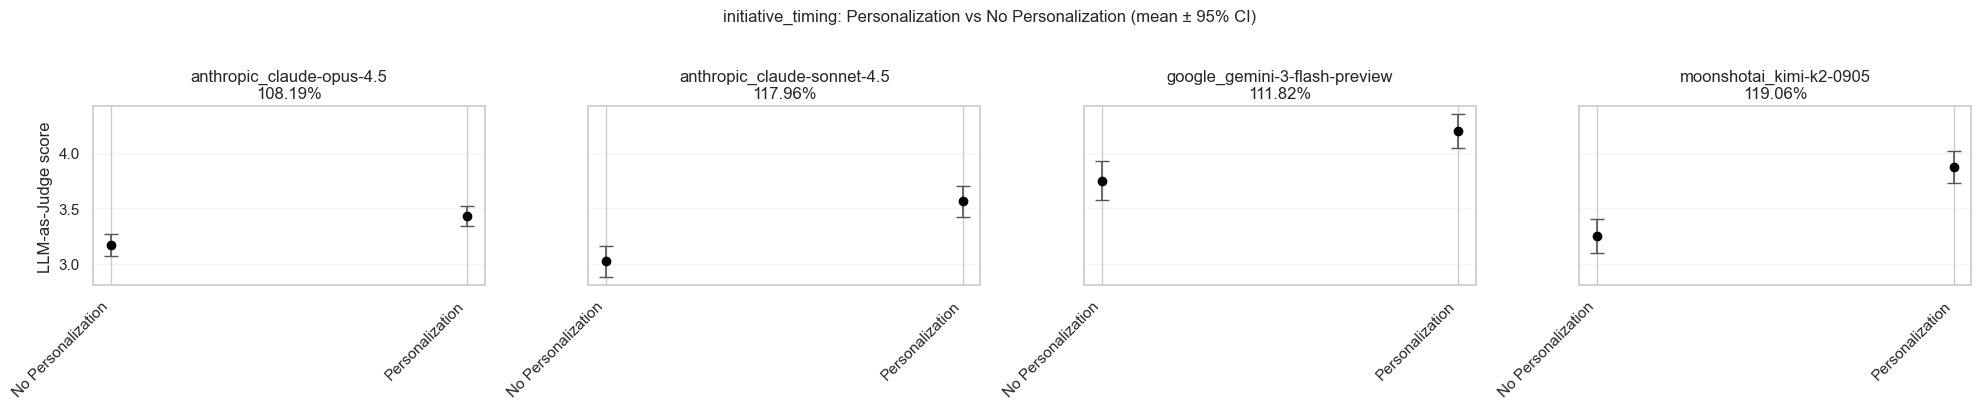

anthropic_claude-opus-4.5 - interaction_coherence: Ratio: 105.05%
anthropic_claude-sonnet-4.5 - interaction_coherence: Ratio: 109.69%
google_gemini-3-flash-preview - interaction_coherence: Ratio: 108.28%
moonshotai_kimi-k2-0905 - interaction_coherence: Ratio: 109.52%


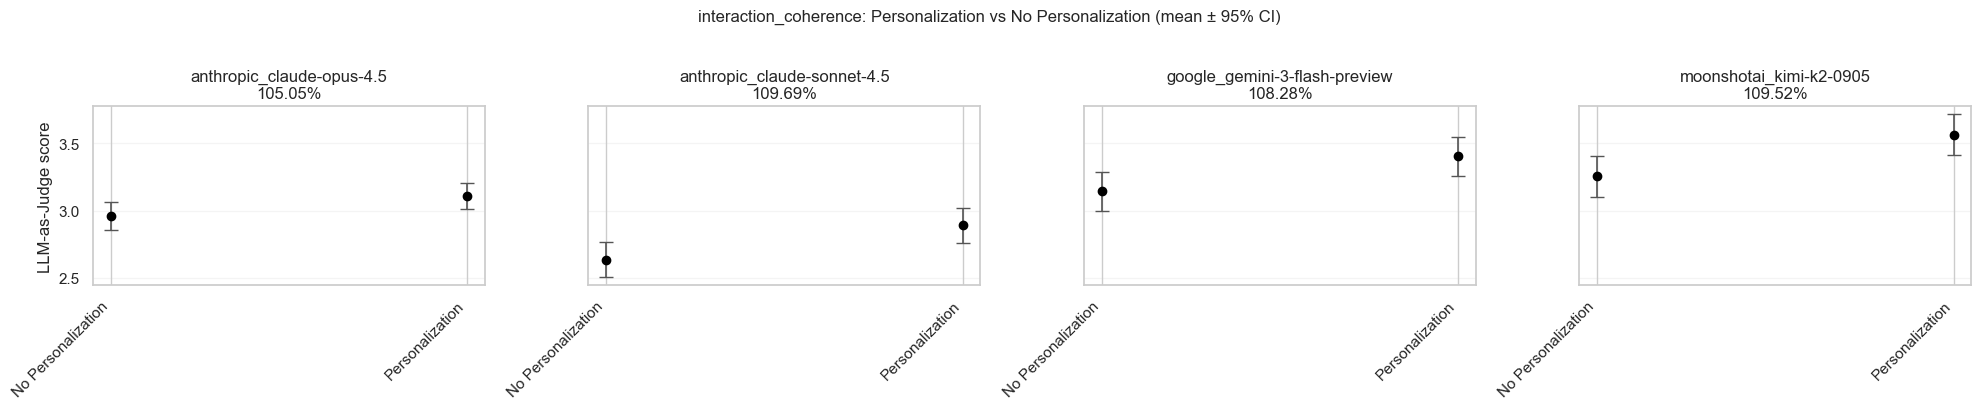

anthropic_claude-opus-4.5 - intent_alignment_drift: Ratio: 107.26%
anthropic_claude-sonnet-4.5 - intent_alignment_drift: Ratio: 105.32%
google_gemini-3-flash-preview - intent_alignment_drift: Ratio: 106.96%
moonshotai_kimi-k2-0905 - intent_alignment_drift: Ratio: 110.61%


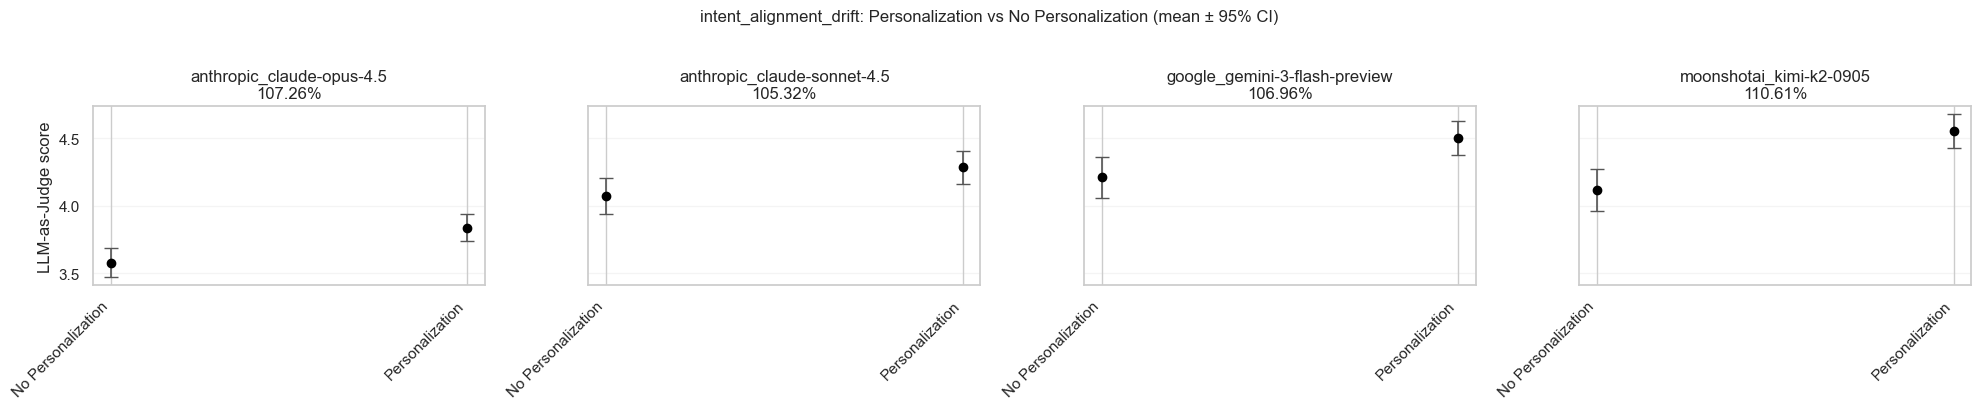

anthropic_claude-opus-4.5 - commitment_consistency: Ratio: 107.41%
anthropic_claude-sonnet-4.5 - commitment_consistency: Ratio: 107.68%
google_gemini-3-flash-preview - commitment_consistency: Ratio: 106.85%
moonshotai_kimi-k2-0905 - commitment_consistency: Ratio: 115.95%


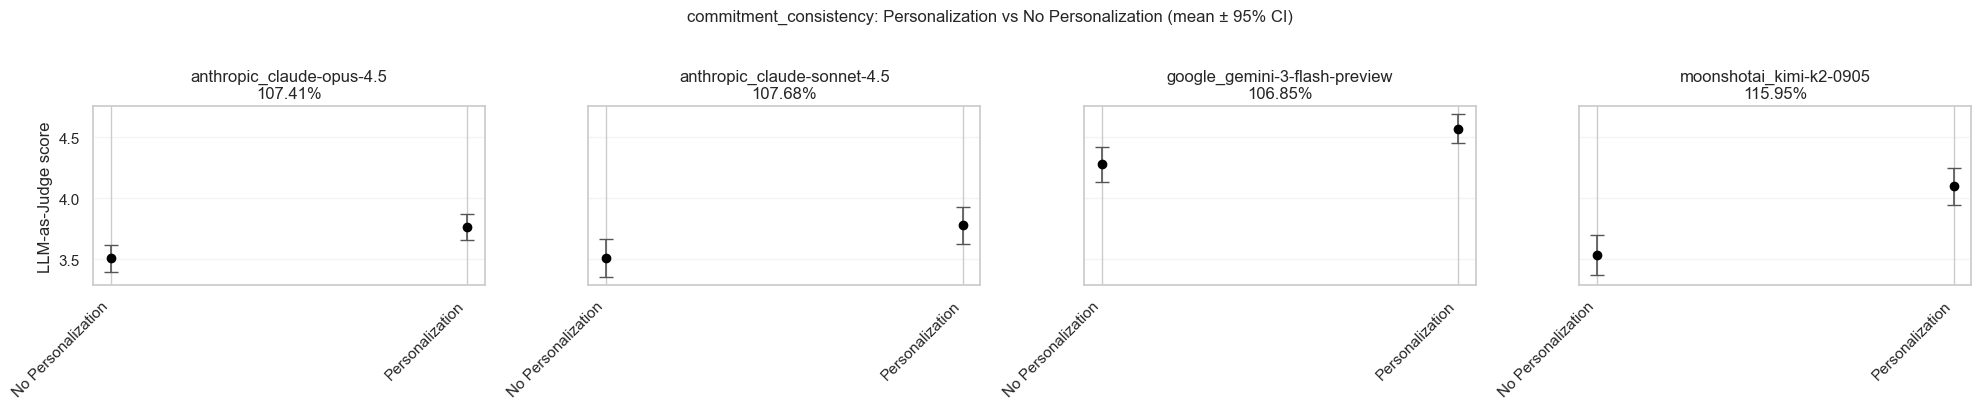

anthropic_claude-opus-4.5 - interaction_preference_alignment: Ratio: 115.89%
anthropic_claude-sonnet-4.5 - interaction_preference_alignment: Ratio: 128.11%
google_gemini-3-flash-preview - interaction_preference_alignment: Ratio: 118.67%
moonshotai_kimi-k2-0905 - interaction_preference_alignment: Ratio: 130.73%


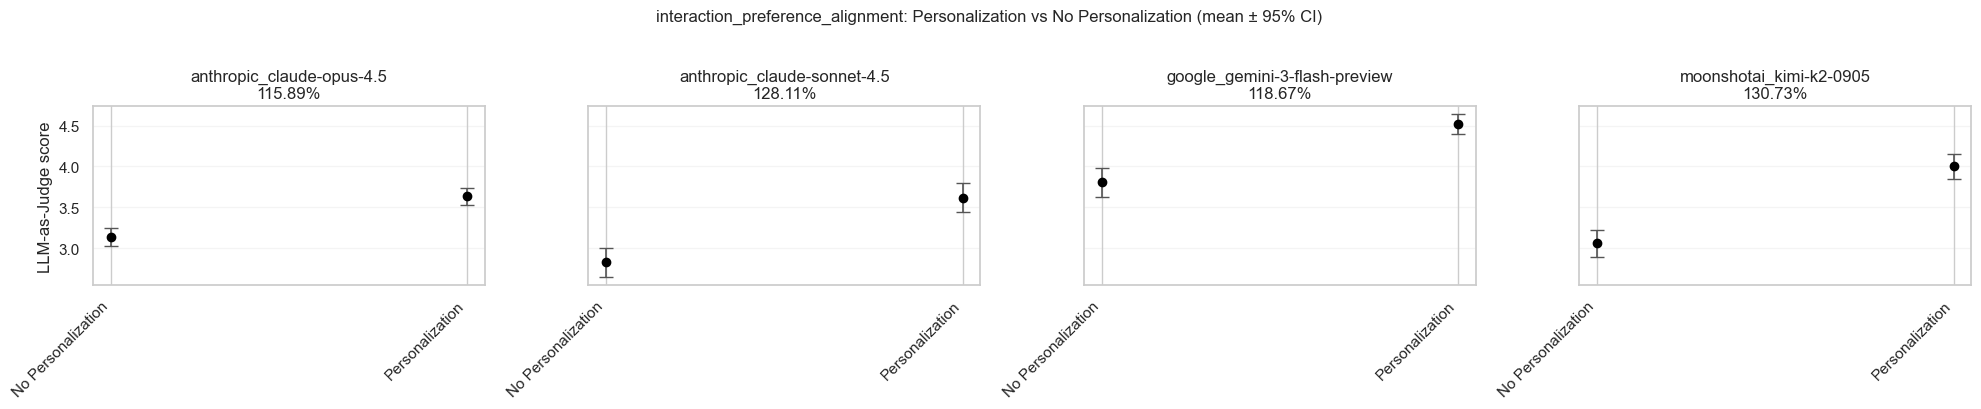

anthropic_claude-opus-4.5 - interaction_efficiency: Ratio: 110.23%
anthropic_claude-sonnet-4.5 - interaction_efficiency: Ratio: 111.21%
google_gemini-3-flash-preview - interaction_efficiency: Ratio: 112.47%
moonshotai_kimi-k2-0905 - interaction_efficiency: Ratio: 106.75%


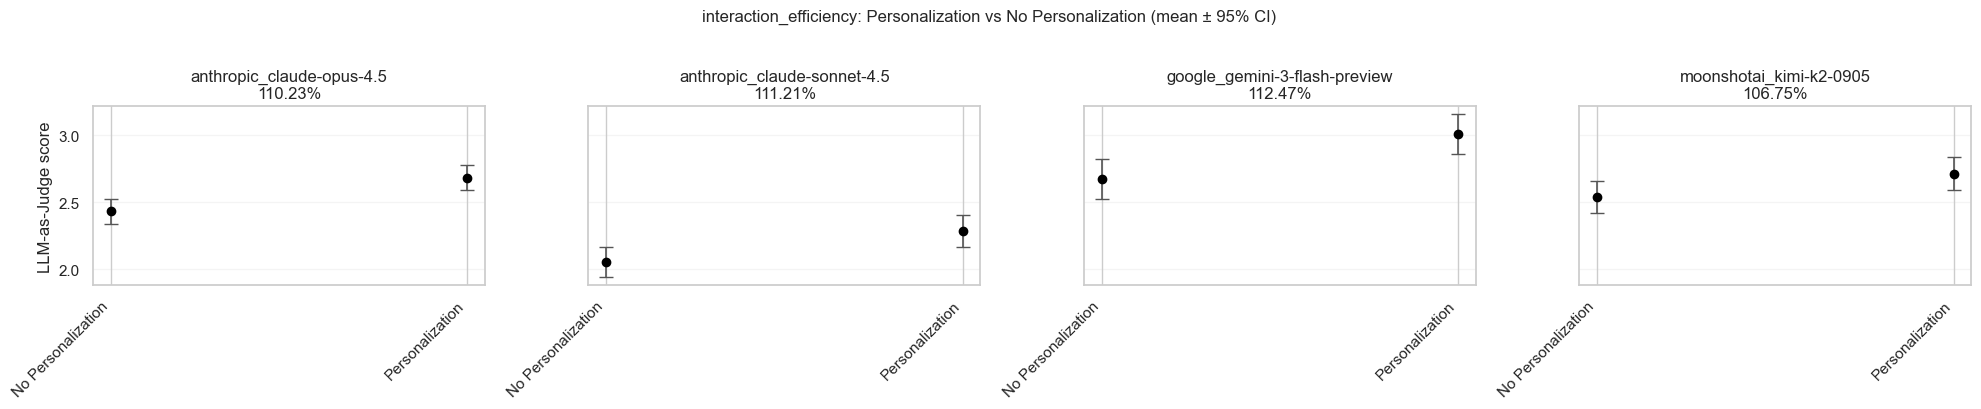

anthropic_claude-opus-4.5 - user_cognitive_load_trajectory: Ratio: 110.04%
anthropic_claude-sonnet-4.5 - user_cognitive_load_trajectory: Ratio: 119.42%
google_gemini-3-flash-preview - user_cognitive_load_trajectory: Ratio: 119.21%
moonshotai_kimi-k2-0905 - user_cognitive_load_trajectory: Ratio: 116.10%


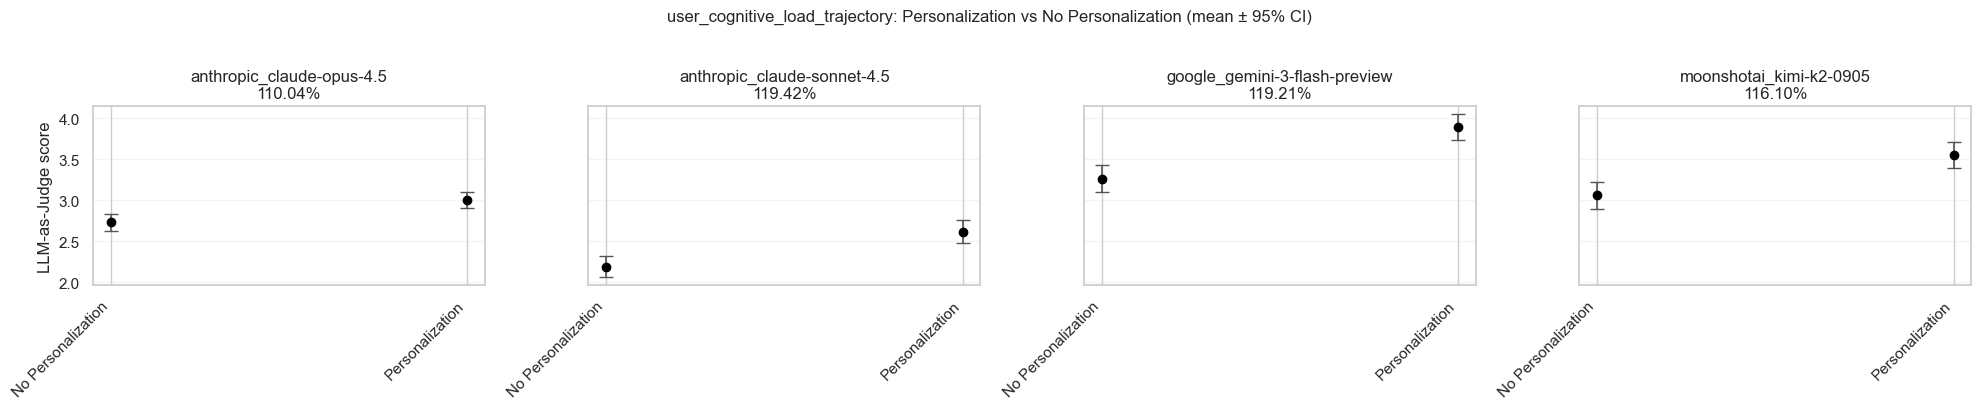

anthropic_claude-opus-4.5 - overall_user_experience: Ratio: 112.47%
anthropic_claude-sonnet-4.5 - overall_user_experience: Ratio: 121.14%
google_gemini-3-flash-preview - overall_user_experience: Ratio: 116.94%
moonshotai_kimi-k2-0905 - overall_user_experience: Ratio: 120.10%


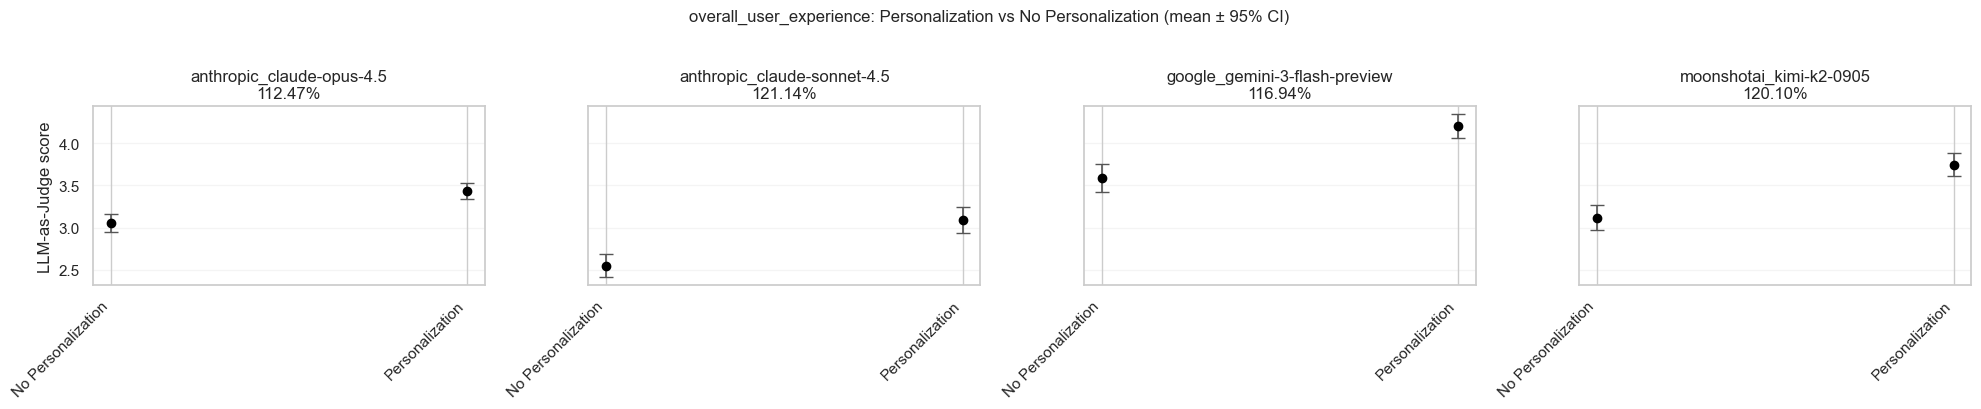

In [96]:
import matplotlib.pyplot as plt
import numpy as np

def plot_condition_errorbar_multimodel(merged_data_dict, dimension, ci=0.95, use_se=False):
    """
    Plot mean score for a dimension under two conditions with error bars for multiple judge models side by side.
    merged_data_dict: dict of {judge_name: merged_dataframe}
    """
    judge_names = list(merged_data_dict.keys())
    n_judges = len(judge_names)
    
    if n_judges == 0:
        raise ValueError("No merged data provided")
    
    fig, axes = plt.subplots(1, n_judges, figsize=(5 * n_judges, 4), sharey=True)
    if n_judges == 1:
        axes = [axes]
    
    z = 1.96 if not use_se else 1.0
    
    all_ratios = []
    
    for idx, judge_name in enumerate(judge_names):
        merged = merged_data_dict[judge_name]
        no_col = f"{dimension}_no"
        p_col = f"{dimension}_p"
        
        if no_col not in merged.columns or p_col not in merged.columns:
            axes[idx].text(0.5, 0.5, f"Missing data\nfor {judge_name}", 
                          ha='center', va='center', transform=axes[idx].transAxes)
            axes[idx].set_title(f"{judge_name}")
            continue
        
        df = merged[[no_col, p_col]].dropna()
        vals = {
            "No Personalization": df[no_col].values,
            "Personalization": df[p_col].values,
        }
        
        means, errs, labels = [], [], []
        for label, arr in vals.items():
            mean = np.mean(arr) if len(arr) else np.nan
            sem = np.std(arr, ddof=1) / np.sqrt(len(arr)) if len(arr) > 1 else 0.0
            err = sem * z if not use_se else sem
            labels.append(label)
            means.append(mean)
            errs.append(err)
        
        # Calculate ratio
        no_mean = means[0]
        p_mean = means[1]
        
        if p_mean >= no_mean:
            ratio = p_mean / no_mean if no_mean != 0 else np.nan
            ratio_text = f"{ratio * 100:.2f}%"
        else:
            ratio = no_mean / p_mean if p_mean != 0 else np.nan
            ratio_text = f"{ratio * 100:.2f}%"
        
        all_ratios.append(ratio_text)
        
        # Print ratio for each judge
        print(f"{judge_name} - {dimension}: Ratio: {ratio_text}")
        
        x = np.arange(len(labels))
        axes[idx].errorbar(
            x, means, yerr=errs, fmt="o", capsize=5, color="black", ecolor="#555",
            elinewidth=1.2, markersize=6,
        )
        axes[idx].set_xticks(x)
        axes[idx].set_xticklabels(labels, rotation=45, ha='right')
        axes[idx].set_ylabel("LLM-as-Judge score" if idx == 0 else "")
        axes[idx].set_title(f"{judge_name}\n{ratio_text}")
        axes[idx].grid(axis="y", alpha=0.2)
    
    fig.suptitle(f"{dimension}: Personalization vs No Personalization (mean ± {'SE' if use_se else '95% CI'})", 
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

# Run for all dimensions
for dim in DIMENSIONS:
    plot_condition_errorbar_multimodel(merged_data, dim, ci=0.95, use_se=False)

In [97]:
# import matplotlib.pyplot as plt
# import numpy as np

# def plot_sorted_delta_curve(merged, dimension):
#     delta_col = f"delta_{dimension}"
#     if delta_col not in merged.columns:
#         raise KeyError(f"Missing column: {delta_col}")

#     deltas = merged[delta_col].dropna().to_numpy()
#     deltas_sorted = np.sort(deltas)  # ascending
#     x = np.arange(len(deltas_sorted))

#     n_neg = np.sum(deltas_sorted < 0)
#     n_pos = np.sum(deltas_sorted > 0)
#     n_zero = np.sum(deltas_sorted == 0)

#     plt.figure(figsize=(7, 4))
#     plt.plot(x, deltas_sorted, color="#1f77b4", linewidth=1.5)
#     plt.axhline(0, color="black", linewidth=1)

#     # optional shading to emphasize negatives vs positives
#     plt.fill_between(x, deltas_sorted, 0, where=deltas_sorted < 0, color="#d62728", alpha=0.2)
#     plt.fill_between(x, deltas_sorted, 0, where=deltas_sorted > 0, color="#1f77b4", alpha=0.15)

#     plt.ylabel(f"Δ {dimension} (personalization - no)")
#     plt.xlabel("test (sorted by delta)")
#     plt.title(
#         f"{dimension}: sorted deltas (neg: {n_neg}, zero: {n_zero}, pos: {n_pos})"
#     )
#     plt.grid(axis="y", alpha=0.25)
#     plt.tight_layout()
#     plt.show()

# # run for all dimensions
# for dim in DIMENSIONS:
#     plot_sorted_delta_curve(merged, dim)

### Single PERSONA analysis

In [98]:
def mean_across_judges(data_dict, label):
    frames = []
    for judge, df in data_dict.items():
        if target_dim not in df.columns:
            continue
        tmp = df[["test_id", "persona", target_dim]].copy()
        tmp["judge"] = judge
        frames.append(tmp)
    if not frames:
        raise ValueError(f"No data: {label}")
    all_scores = pd.concat(frames, ignore_index=True)
    per_sample = (
        all_scores.groupby(["test_id", "persona"])[target_dim]
        .mean()
        .reset_index(name="mean_score_across_judges")
    )
    overall_mean = per_sample["mean_score_across_judges"].mean()
    return per_sample, overall_mean

# Compute per-sample mean across judges, then global mean and personalization/no_personalization ratio
for target_dim in DIMENSIONS:
    print(f"=== {target_dim} ===")
    no_sample_mean, no_overall_mean = mean_across_judges(no_personalization_data, "no_personalization")
    p_sample_mean, p_overall_mean = mean_across_judges(personalization_data, "personalization")
    ratio = p_overall_mean / no_overall_mean if no_overall_mean else np.nan
    print("No personalization overall mean:", no_overall_mean)
    print("Personalization overall mean:", p_overall_mean)
    print("Personalization / No personalization ratio:", ratio)
    print("\nPer-sample mean across judges (no_personalization):")
    # display(no_sample_mean.head())
    # print("\nPer-sample mean across judges (personalization):")
    # display(p_sample_mean.head())
    # print("\n\n")




=== initiative_timing ===
No personalization overall mean: 3.2975768321513006
Personalization overall mean: 3.75177304964539
Personalization / No personalization ratio: 1.1377363563043281

Per-sample mean across judges (no_personalization):
=== interaction_coherence ===
No personalization overall mean: 2.9940898345153664
Personalization overall mean: 3.229314420803783
Personalization / No personalization ratio: 1.078562968811686

Per-sample mean across judges (no_personalization):
=== intent_alignment_drift ===
No personalization overall mean: 3.9890661938534273
Personalization overall mean: 4.283983451536644
Personalization / No personalization ratio: 1.0739314023260986

Per-sample mean across judges (no_personalization):
=== commitment_consistency ===
No personalization overall mean: 3.7006501182033102
Personalization overall mean: 4.044030732860519
Personalization / No personalization ratio: 1.0927892677473445

Per-sample mean across judges (no_personalization):
=== interaction_pref

In [99]:
# Compute overall mean and ratio per dimension and put into a new DataFrame

dim_list = []
no_means = []
p_means = []
ratios = []

for target_dim in DIMENSIONS:
    no_sample_mean, no_overall_mean = mean_across_judges(no_personalization_data, "no_personalization")
    p_sample_mean, p_overall_mean = mean_across_judges(personalization_data, "personalization")
    ratio = 100*(p_overall_mean / no_overall_mean) if no_overall_mean else np.nan

    dim_list.append(target_dim)
    no_means.append(no_overall_mean)
    p_means.append(p_overall_mean)
    ratios.append(ratio)

df_compare = pd.DataFrame({
    "dimension": dim_list,
    "no_personalization": no_means,
    "personalization": p_means,
    "ratio": ratios,
})
display(df_compare)


,dimension,no_personalization,personalization,ratio
0,initiative_timing,3.297577,3.751773,113.773636
1,interaction_coherence,2.994090,3.229314,107.856297
2,intent_alignment_drift,3.989066,4.283983,107.393140
3,commitment_consistency,3.700650,4.044031,109.278927
4,interaction_preference_alignment,3.210106,3.929669,122.415539
5,interaction_efficiency,2.421690,2.663416,109.981696
6,user_cognitive_load_trajectory,2.807033,3.249409,115.759554
7,overall_user_experience,3.078605,3.601359,116.980227


In [100]:
df_compare.to_csv(
    "<PROJECT_ROOT>/Desktop/Desktop - ADUAED19365LPMX/Agent_IX_Personalization/gorilla/berkeley-function-call-leaderboard/bfcl_eval/LLM_as_judge_analysis/compare/df_compare_sonnet.csv",
    index=False
)
